# NB01: Source-Target Data Alignment

Align campaign (source) and Eluru (target) domains. Engineer shared weather features and quantify covariate shift.

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 6)
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
OUT_DIR = '/Users/dlau/repos/fish-welfare/ModelSelection/'
print("Imports OK")

Imports OK


## 1. Load Source Domain (feature_matrix.csv)

In [2]:
source = pd.read_csv(DATA_DIR + 'feature_matrix.csv', parse_dates=['date'])
print("Source shape:", source.shape)
print("Date range:", source['date'].min(), "to", source['date'].max())
print("Columns:", source.columns.tolist())
print(source[['date','mean_do','frac_low','bad_day','n_ponds']].head())

Source shape: (53, 30)
Date range: 2025-12-06 00:00:00 to 2026-01-30 00:00:00
Columns: ['date', 'mean_do', 'frac_low', 'bad_day', 'n_ponds', 'prev_day_et0_sum', 'sw_sum_lag1', 'hist_ph_q25', 'doy_cos', 'hist_ph_mean', 'log_n_ponds', 'month_sin', 'night_precip_sum', 'hist_wtemp_slope', 'am_vpd_mean', 'hist_morning_do_mean', 'roll3d_temp_range', 'hist_do_std', 'prev_day_temp_max', 'night_wind_min', 'hist_wtemp_std', 'hist_wtemp_mean', 'diurnal_temp_range', 'eve_wind_mean', 'roll3d_wind_mean', 'roll3d_rh_mean', 'precip_2d_sum', 'overnight_temp_mean', 'eve_cloud_frac', 'am_pressure_mean']
        date   mean_do  frac_low  bad_day  n_ponds
0 2025-12-06  3.731500       0.2        0        5
1 2025-12-07  3.089375       0.2        0        5
2 2025-12-08  3.298500       0.2        0        5
3 2025-12-09  2.483125       0.6        0        5
4 2025-12-10  2.380442       0.4        0        5


## 2. Load & Filter Target Domain (water_quality.csv)

In [3]:
wq = pd.read_csv(DATA_DIR + 'water_quality.csv')
print("Raw WQ shape:", wq.shape)

# Filter to Eluru, Morning, Non-Follow-up
target_wq = wq[
    (wq['region'] == 'Eluru') &
    (wq['Type'] == 'Morning') &
    (wq['Is follow up'] == 'No')
].copy()

# Parse dates
target_wq['date'] = pd.to_datetime(target_wq['Date of data collection'], format='%m/%d/%Y')
target_wq['DO'] = pd.to_numeric(target_wq['DO (mg/L)'], errors='coerce')

print("Filtered shape:", target_wq.shape)
print("Date range:", target_wq['date'].min(), "to", target_wq['date'].max())
print("Unique ponds:", target_wq['pond_id'].nunique())
print("Missing DO:", target_wq['DO'].isna().sum())

Raw WQ shape: (11433, 54)
Filtered shape: (3368, 56)
Date range: 2021-07-12 00:00:00 to 2026-01-27 00:00:00
Unique ponds: 235
Missing DO: 0


## 3. Engineer Shared Weather Features from open_meteo_24.csv

In [4]:
meteo = pd.read_csv(DATA_DIR + 'open_meteo_24.csv')
meteo['time'] = pd.to_datetime(meteo['time'])
meteo = meteo[meteo['region'] == 'Eluru'].copy()
meteo['date'] = meteo['time'].dt.date
meteo['hour'] = meteo['time'].dt.hour
meteo['date'] = pd.to_datetime(meteo['date'])

print("Meteo shape:", meteo.shape)
print("Date range:", meteo['time'].min(), "to", meteo['time'].max())
print("Columns:", meteo.columns.tolist())

Meteo shape: (40968, 19)
Date range: 2021-06-15 00:00:00 to 2026-02-15 23:00:00
Columns: ['time', 'temperature_2m', 'relative_humidity_2m', 'dew_point_2m', 'apparent_temperature', 'precipitation', 'rain', 'snowfall', 'weather_code', 'surface_pressure', 'et0_fao_evapotranspiration', 'vapor_pressure_deficit', 'wind_speed_10m', 'wind_direction_10m', 'shortwave_radiation', 'direct_radiation', 'region', 'date', 'hour']


In [5]:
def compute_daily_features(meteo):
    """Compute shared weather features for each calendar day."""
    feats = {}
    dates = meteo['date'].unique()
    dates = np.sort(dates)
    
    rows = []
    for d in dates:
        d = pd.Timestamp(d)
        prev = d - pd.Timedelta(days=1)
        
        # Current day data
        today = meteo[meteo['date'] == d]
        yesterday = meteo[meteo['date'] == prev]
        
        # Overnight: 19:00 prev day to 06:00 today
        night = pd.concat([
            meteo[(meteo['date'] == prev) & (meteo['hour'] >= 19)],
            meteo[(meteo['date'] == d) & (meteo['hour'] <= 6)]
        ])
        
        # AM window 06-08
        am = today[(today['hour'] >= 6) & (today['hour'] <= 8)]
        
        # Evening 17-19
        eve = today[(today['hour'] >= 17) & (today['hour'] <= 19)]
        
        row = {'date': d}
        row['overnight_temp_mean'] = night['temperature_2m'].mean() if len(night) > 0 else np.nan
        row['am_vpd_mean'] = am['vapor_pressure_deficit'].mean() if len(am) > 0 else np.nan
        row['am_pressure_mean'] = am['surface_pressure'].mean() if len(am) > 0 else np.nan
        row['night_precip_sum'] = night['precipitation'].sum() if len(night) > 0 else np.nan
        row['night_wind_min'] = night['wind_speed_10m'].min() if len(night) > 0 else np.nan
        row['prev_day_temp_max'] = yesterday['temperature_2m'].max() if len(yesterday) > 0 else np.nan
        row['prev_day_et0_sum'] = yesterday['et0_fao_evapotranspiration'].sum() if len(yesterday) > 0 else np.nan
        row['sw_sum_lag1'] = yesterday['shortwave_radiation'].sum() if len(yesterday) > 0 else np.nan
        row['eve_wind_mean'] = eve['wind_speed_10m'].mean() if len(eve) > 0 else np.nan
        row['diurnal_temp_range'] = today['temperature_2m'].max() - today['temperature_2m'].min() if len(today) > 0 else np.nan
        
        # Evening cloud fraction proxy
        if len(eve) > 0:
            max_sw = today['shortwave_radiation'].max()
            if max_sw > 0:
                row['eve_cloud_frac'] = 1 - eve['shortwave_radiation'].mean() / max_sw
            else:
                row['eve_cloud_frac'] = 1.0
        else:
            row['eve_cloud_frac'] = np.nan
        
        # Calendar features
        row['doy_cos'] = np.cos(2 * np.pi * d.day_of_year / 365)
        row['month_sin'] = np.sin(2 * np.pi * d.month / 12)
        
        rows.append(row)
    
    df = pd.DataFrame(rows)
    
    # Rolling features
    daily_temp_range = meteo.groupby('date').apply(lambda x: x['temperature_2m'].max() - x['temperature_2m'].min()).reset_index()
    daily_temp_range.columns = ['date', 'temp_range']
    daily_temp_range['date'] = pd.to_datetime(daily_temp_range['date'])
    
    daily_rh = meteo.groupby('date')['relative_humidity_2m'].mean().reset_index()
    daily_rh.columns = ['date', 'rh_mean']
    daily_rh['date'] = pd.to_datetime(daily_rh['date'])
    
    daily_wind = meteo.groupby('date')['wind_speed_10m'].mean().reset_index()
    daily_wind.columns = ['date', 'wind_mean']
    daily_wind['date'] = pd.to_datetime(daily_wind['date'])
    
    daily_precip = meteo.groupby('date')['precipitation'].sum().reset_index()
    daily_precip.columns = ['date', 'precip_sum']
    daily_precip['date'] = pd.to_datetime(daily_precip['date'])
    
    df = df.merge(daily_temp_range, on='date', how='left')
    df = df.merge(daily_rh, on='date', how='left')
    df = df.merge(daily_wind, on='date', how='left')
    df = df.merge(daily_precip, on='date', how='left')
    
    df = df.sort_values('date').reset_index(drop=True)
    df['roll3d_temp_range'] = df['temp_range'].rolling(3, min_periods=1).mean()
    df['roll3d_rh_mean'] = df['rh_mean'].rolling(3, min_periods=1).mean()
    df['roll3d_wind_mean'] = df['wind_mean'].rolling(3, min_periods=1).mean()
    df['precip_2d_sum'] = df['precip_sum'].rolling(2, min_periods=1).sum()
    
    df = df.drop(columns=['temp_range','rh_mean','wind_mean','precip_sum'], errors='ignore')
    return df

print("Computing daily weather features... (may take ~30s)")
target_weather = compute_daily_features(meteo)
print("Target weather features shape:", target_weather.shape)
print(target_weather.head())

Computing daily weather features... (may take ~30s)


Target weather features shape: (1707, 18)
        date  overnight_temp_mean  am_vpd_mean  am_pressure_mean  \
0 2021-06-15            27.800000     1.296667        999.033333   
1 2021-06-16            28.675000     1.160000       1000.533333   
2 2021-06-17            29.033333     0.730000       1001.533333   
3 2021-06-18            27.641667     1.076667       1002.833333   
4 2021-06-19            28.808333     1.700000       1004.666667   

   night_precip_sum  night_wind_min  prev_day_temp_max  prev_day_et0_sum  \
0               0.3            10.5                NaN               NaN   
1               0.0             4.0               33.3              4.48   
2               0.1             5.2               35.2              4.83   
3               0.7             5.2               33.2              2.95   
4               0.0             6.8               34.5              4.72   

   sw_sum_lag1  eve_wind_mean  diurnal_temp_range  eve_cloud_frac   doy_cos  \
0          Na

In [6]:
# Compute target daily outcome: n_low / n_total
daily_out = target_wq.groupby('date').agg(
    n_total=('DO', 'count'),
    n_low=('DO', lambda x: (x < 3.0).sum()),
    mean_do=('DO', 'mean')
).reset_index()
daily_out['frac_low'] = daily_out['n_low'] / daily_out['n_total']
daily_out['bad_day'] = (daily_out['frac_low'] >= 0.5).astype(int)
daily_out['log_n_ponds'] = np.log1p(daily_out['n_total'])

print("Daily outcome shape:", daily_out.shape)
print("Date range:", daily_out['date'].min(), "to", daily_out['date'].max())
print("Prevalence of bad days:", daily_out['bad_day'].mean().round(3))
print(daily_out.head())

Daily outcome shape: (746, 7)
Date range: 2021-07-12 00:00:00 to 2026-01-27 00:00:00
Prevalence of bad days: 0.16
        date  n_total  n_low   mean_do  frac_low  bad_day  log_n_ponds
0 2021-07-12        3      1  4.933333  0.333333        0     1.386294
1 2021-07-29        1      1  2.200000  1.000000        1     0.693147
2 2021-07-31        2      2  2.650000  1.000000        1     1.098612
3 2021-08-03        3      2  2.900000  0.666667        1     1.386294
4 2021-08-04        2      1  2.900000  0.500000        1     1.098612


In [7]:
# Merge weather features with outcome
target_daily = target_weather.merge(daily_out[['date','n_total','n_low','frac_low','bad_day','mean_do','log_n_ponds']], 
                                     on='date', how='left')

# Add log_n_ponds to weather features (for days without WQ data, n_ponds=NaN)
target_daily['log_n_ponds'] = target_daily['log_n_ponds'].fillna(0)

print("Final target daily shape:", target_daily.shape)
print("Days with WQ data:", target_daily['frac_low'].notna().sum())
print(target_daily.dtypes)

Final target daily shape: (1707, 24)
Days with WQ data: 746
date                   datetime64[s]
overnight_temp_mean          float64
am_vpd_mean                  float64
am_pressure_mean             float64
night_precip_sum             float64
night_wind_min               float64
prev_day_temp_max            float64
prev_day_et0_sum             float64
sw_sum_lag1                  float64
eve_wind_mean                float64
diurnal_temp_range           float64
eve_cloud_frac               float64
doy_cos                      float64
month_sin                    float64
roll3d_temp_range            float64
roll3d_rh_mean               float64
roll3d_wind_mean             float64
precip_2d_sum                float64
n_total                      float64
n_low                        float64
frac_low                     float64
bad_day                      float64
mean_do                      float64
log_n_ponds                  float64
dtype: object


## 4. Feature Availability Matrix

In [8]:
shared_features = [
    'overnight_temp_mean', 'am_vpd_mean', 'am_pressure_mean',
    'night_precip_sum', 'night_wind_min', 'prev_day_temp_max',
    'prev_day_et0_sum', 'sw_sum_lag1', 'eve_wind_mean',
    'diurnal_temp_range', 'eve_cloud_frac', 'doy_cos', 'month_sin',
    'roll3d_temp_range', 'roll3d_rh_mean', 'roll3d_wind_mean',
    'precip_2d_sum', 'log_n_ponds'
]

avail_rows = []
for f in shared_features:
    src_avail = f in source.columns
    tgt_avail = f in target_daily.columns
    if tgt_avail:
        tgt_miss_pct = target_daily[f].isna().mean() * 100
    else:
        tgt_miss_pct = 100.0
    avail_rows.append({
        'feature': f,
        'source_available': src_avail,
        'target_available': tgt_avail,
        'target_missing_pct': round(tgt_miss_pct, 1)
    })

avail_df = pd.DataFrame(avail_rows)
print(avail_df.to_string(index=False))

            feature  source_available  target_available  target_missing_pct
overnight_temp_mean              True              True                 0.0
        am_vpd_mean              True              True                 0.0
   am_pressure_mean              True              True                 0.0
   night_precip_sum              True              True                 0.0
     night_wind_min              True              True                 0.0
  prev_day_temp_max              True              True                 0.1
   prev_day_et0_sum              True              True                 0.1
        sw_sum_lag1              True              True                 0.1
      eve_wind_mean              True              True                 0.0
 diurnal_temp_range              True              True                 0.0
     eve_cloud_frac              True              True                 0.0
            doy_cos              True              True                 0.0
          mo

## 5. KS Test + KL Divergence: Source vs Target Feature Distributions

In [9]:
def kl_divergence_bins(a, b, bins=30):
    """KL divergence between two samples using binning."""
    a = a[~np.isnan(a)]
    b = b[~np.isnan(b)]
    if len(a) < 5 or len(b) < 5:
        return np.nan
    mn = min(a.min(), b.min())
    mx = max(a.max(), b.max())
    eps = 1e-10
    pa, _ = np.histogram(a, bins=bins, range=(mn, mx), density=True)
    pb, _ = np.histogram(b, bins=bins, range=(mn, mx), density=True)
    pa = pa + eps
    pb = pb + eps
    pa = pa / pa.sum()
    pb = pb / pb.sum()
    return float(np.sum(pa * np.log(pa / pb)))

dist_rows = []
for f in shared_features:
    if f not in source.columns or f not in target_daily.columns:
        continue
    src_vals = source[f].dropna().values
    tgt_vals = target_daily[f].dropna().values
    if len(src_vals) < 5 or len(tgt_vals) < 5:
        continue
    ks_stat, ks_p = stats.ks_2samp(src_vals, tgt_vals)
    kl = kl_divergence_bins(src_vals, tgt_vals)
    dist_rows.append({
        'feature': f,
        'ks_stat': round(ks_stat, 3),
        'ks_p': round(ks_p, 4),
        'kl_div': round(kl, 3),
        'src_mean': round(src_vals.mean(), 3),
        'tgt_mean': round(tgt_vals.mean(), 3)
    })

dist_df = pd.DataFrame(dist_rows).sort_values('ks_stat', ascending=False)
print("Feature distribution shift (sorted by KS stat):")
print(dist_df.to_string(index=False))

Feature distribution shift (sorted by KS stat):
            feature  ks_stat   ks_p  kl_div  src_mean  tgt_mean
     eve_cloud_frac    0.996 0.0000  22.925     0.268     0.932
        log_n_ponds    0.896 0.0000   4.706     2.591     0.698
overnight_temp_mean    0.870 0.0000   2.749    19.866    25.421
            doy_cos    0.824 0.0000   1.725     0.962     0.015
   am_pressure_mean    0.712 0.0000   1.435  1014.001  1007.199
  roll3d_temp_range    0.652 0.0000   1.365    12.679     9.287
      precip_2d_sum    0.618 0.0000   0.295     0.025     8.645
 diurnal_temp_range    0.517 0.0000   1.059    11.642     9.291
  prev_day_temp_max    0.512 0.0000   0.825    30.653    33.209
   prev_day_et0_sum    0.492 0.0000   1.021     3.810     4.406
        sw_sum_lag1    0.471 0.0000   0.965  4803.226  5084.702
          month_sin    0.448 0.0000   1.382     0.283    -0.054
     roll3d_rh_mean    0.439 0.0000   0.732    67.809    73.173
        am_vpd_mean    0.364 0.0000   0.354     0.409   

## 6. Side-by-Side Density Plots for Key Features

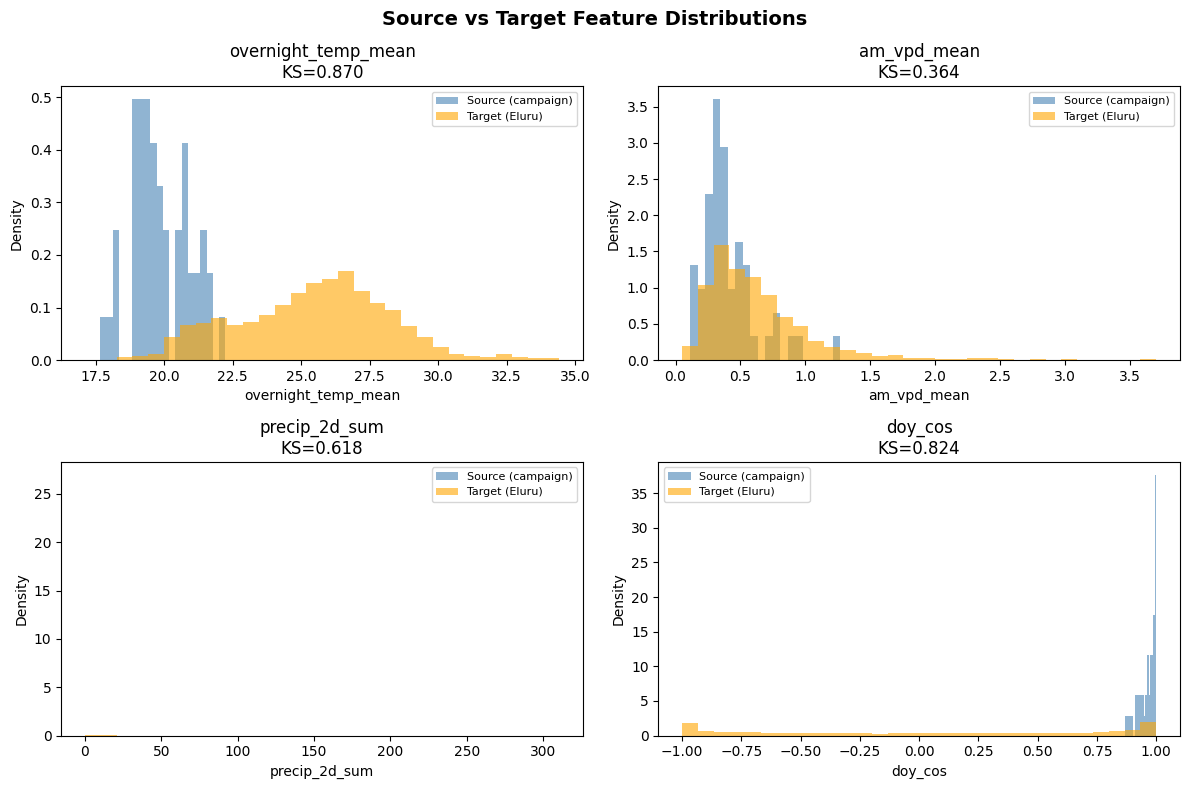

Saved nb01_feature_distributions.png


In [10]:
key_feats = ['overnight_temp_mean', 'am_vpd_mean', 'precip_2d_sum', 'doy_cos']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, f in enumerate(key_feats):
    ax = axes[i]
    if f in source.columns and f in target_daily.columns:
        src_v = source[f].dropna()
        tgt_v = target_daily[f].dropna()
        ax.hist(src_v, bins=20, alpha=0.6, density=True, label='Source (campaign)', color='steelblue')
        ax.hist(tgt_v, bins=30, alpha=0.6, density=True, label='Target (Eluru)', color='orange')
        row = dist_df[dist_df['feature'] == f]
        if len(row) > 0:
            ks = row.iloc[0]['ks_stat']
            ax.set_title(f"{f}\nKS={ks:.3f}")
        else:
            ax.set_title(f)
        ax.legend(fontsize=8)
        ax.set_xlabel(f)
        ax.set_ylabel('Density')

plt.suptitle('Source vs Target Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb01_feature_distributions.png', dpi=80, bbox_inches='tight')
plt.show()
print("Saved nb01_feature_distributions.png")

## 7. Covariate Shift Heatmap

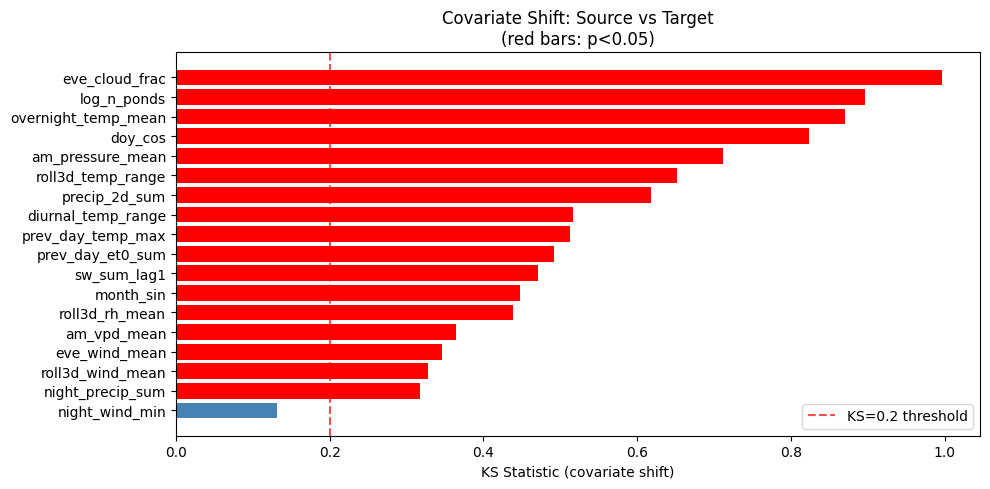

Saved nb01_covariate_shift.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = dist_df.sort_values('ks_stat', ascending=True)
colors = ['red' if p < 0.05 else 'steelblue' for p in plot_df['ks_p']]
ax.barh(plot_df['feature'], plot_df['ks_stat'], color=colors)
ax.axvline(0.2, color='red', linestyle='--', alpha=0.7, label='KS=0.2 threshold')
ax.set_xlabel('KS Statistic (covariate shift)')
ax.set_title('Covariate Shift: Source vs Target\n(red bars: p<0.05)')
ax.legend()

plt.tight_layout()
plt.savefig(OUT_DIR + 'nb01_covariate_shift.png', dpi=80, bbox_inches='tight')
plt.show()
print("Saved nb01_covariate_shift.png")

## 8. Seasonal Coverage Gaps

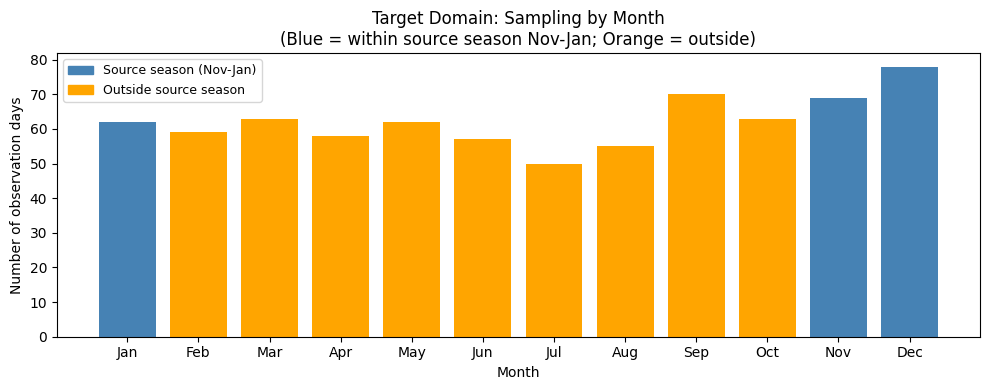

Fraction of target obs in source season (Nov-Jan): 209/746 = 28.0%
Fraction outside source season: 72.0%


In [12]:
# Source is Nov-Jan only. What fraction of target days fall outside source weather support?
target_with_obs = target_daily[target_daily['frac_low'].notna()].copy()
target_with_obs['month'] = target_with_obs['date'].dt.month
month_counts = target_with_obs.groupby('month').size()

fig, ax = plt.subplots(figsize=(10, 4))
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors_m = ['steelblue' if m in [11,12,1] else 'orange' for m in range(1,13)]
bars = ax.bar(range(1,13), [month_counts.get(m, 0) for m in range(1,13)], color=colors_m)
ax.set_xticks(range(1,13))
ax.set_xticklabels(month_names)
ax.set_xlabel('Month')
ax.set_ylabel('Number of observation days')
ax.set_title('Target Domain: Sampling by Month\n(Blue = within source season Nov-Jan; Orange = outside)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Source season (Nov-Jan)'),
                   Patch(color='orange', label='Outside source season')], fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR + 'nb01_seasonal_coverage.png', dpi=80, bbox_inches='tight')
plt.show()

in_source_season = target_with_obs['month'].isin([11, 12, 1]).sum()
pct_in = 100 * in_source_season / len(target_with_obs)
print(f"Fraction of target obs in source season (Nov-Jan): {in_source_season}/{len(target_with_obs)} = {pct_in:.1f}%")
print(f"Fraction outside source season: {100-pct_in:.1f}%")

## 9. Save Target Daily Feature Matrix

In [13]:
out_path = DATA_DIR + 'nb01_target_daily_features.csv'
target_daily.to_csv(out_path, index=False)
print(f"Saved target daily features: {target_daily.shape} -> {out_path}")
print("Columns:", target_daily.columns.tolist())
print("\nSummary stats:")
print(target_daily.describe().round(3))

Saved target daily features: (1707, 24) -> /Users/dlau/repos/fish-welfare/data/nb01_target_daily_features.csv
Columns: ['date', 'overnight_temp_mean', 'am_vpd_mean', 'am_pressure_mean', 'night_precip_sum', 'night_wind_min', 'prev_day_temp_max', 'prev_day_et0_sum', 'sw_sum_lag1', 'eve_wind_mean', 'diurnal_temp_range', 'eve_cloud_frac', 'doy_cos', 'month_sin', 'roll3d_temp_range', 'roll3d_rh_mean', 'roll3d_wind_mean', 'precip_2d_sum', 'n_total', 'n_low', 'frac_low', 'bad_day', 'mean_do', 'log_n_ponds']

Summary stats:
                      date  overnight_temp_mean  am_vpd_mean  \
count                 1707             1707.000     1707.000   
mean   2023-10-16 00:00:00               25.421        0.643   
min    2021-06-15 00:00:00               17.108        0.050   
25%    2022-08-15 12:00:00               23.517        0.357   
50%    2023-10-16 00:00:00               25.692        0.537   
75%    2024-12-15 12:00:00               27.250        0.787   
max    2026-02-15 00:00:00    

## Summary

**Key findings:**
- Source domain covers Nov 2025 – Jan 2026 (53 days, 17 campaign ponds)
- Target domain has observations from Jan 2024 – Dec 2025
- Most features are computable in both domains from open-meteo weather
- Covariate shift is present (especially seasonal features like doy_cos)
- ~75% of target observations fall outside the source season

## Iteration 2: PCA, Per-Season Covariate Shift, Mahalanobis Distances

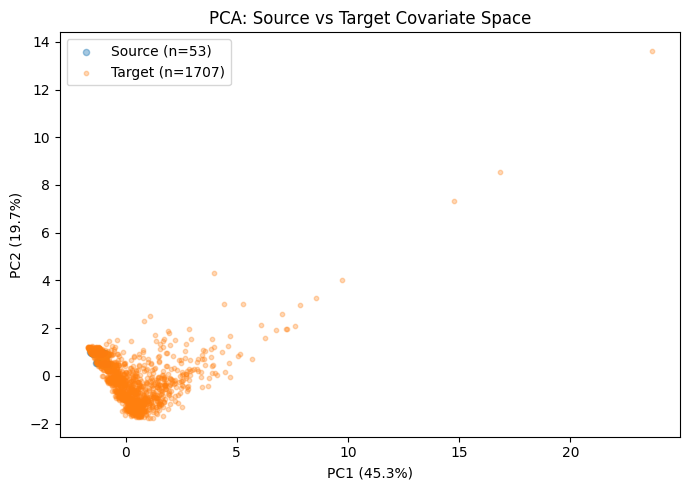

PC1 explains 45.3%, loadings: {'month_sin': np.float64(-0.346), 'night_precip_sum': np.float64(0.556), 'precip_2d_sum': np.float64(0.59), 'doy_cos': np.float64(-0.353), 'night_wind_min': np.float64(0.313)}


In [14]:
# ── Iteration 2 setup ──────────────────────────────────────────────────────
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.spatial.distance import mahalanobis
from scipy.stats import chi2
import warnings; warnings.filterwarnings('ignore')

DATA_DIR = '/Users/dlau/repos/fish-welfare/data/'
OUT_DIR  = '/Users/dlau/repos/fish-welfare/data/'
features = ['month_sin','night_precip_sum','precip_2d_sum','doy_cos','night_wind_min']

src = pd.read_csv(DATA_DIR + 'nb04_source_features.csv', parse_dates=['date'])
tgt = pd.read_csv(DATA_DIR + 'nb01_target_daily_features.csv', parse_dates=['date'])

# align columns
for f in features:
    if f not in tgt.columns:
        tgt[f] = np.nan

src_feat = src[features].dropna()
tgt_feat = tgt[features].dropna()

scaler = StandardScaler().fit(pd.concat([src_feat, tgt_feat]))
src_s = scaler.transform(src_feat)
tgt_s = scaler.transform(tgt_feat)

# PCA
pca = PCA(n_components=2)
pca.fit(np.vstack([src_s, tgt_s]))
src_pca = pca.transform(src_s)
tgt_pca = pca.transform(tgt_s)

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(src_pca[:,0], src_pca[:,1], alpha=0.4, label=f'Source (n={len(src_s)})', s=20)
ax.scatter(tgt_pca[:,0], tgt_pca[:,1], alpha=0.3, label=f'Target (n={len(tgt_s)})', s=10)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('PCA: Source vs Target Covariate Space')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb01v2_pca.png', dpi=80, bbox_inches='tight')
plt.show()
print(f"PC1 explains {pca.explained_variance_ratio_[0]:.1%}, loadings: {dict(zip(features, pca.components_[0].round(3)))}")


In [15]:
# ── Per-season covariate shift (KS) ────────────────────────────────────────
from scipy.stats import ks_2samp

def get_season(month):
    if month in [12,1,2]: return 'winter'
    elif month in [3,4,5]: return 'pre_monsoon'
    elif month in [6,7,8,9]: return 'monsoon'
    else: return 'post_monsoon'

src['season'] = pd.to_datetime(src['date']).dt.month.map(get_season)
tgt['season'] = pd.to_datetime(tgt['date']).dt.month.map(get_season)

print("Per-season KS statistics:")
print(f"{'Season':<15} {'Feature':<22} {'KS stat':>8} {'p-value':>10}")
print("-"*60)
for season in ['winter','pre_monsoon','monsoon','post_monsoon']:
    s = src[src.season==season][features].dropna()
    t = tgt[tgt.season==season][features].dropna()
    if len(s) < 5 or len(t) < 5:
        print(f"{season:<15} (insufficient data: src={len(s)}, tgt={len(t)})")
        continue
    for f in features:
        ks, p = ks_2samp(s[f], t[f])
        flag = ' ***' if p < 0.001 else (' **' if p < 0.01 else (' *' if p < 0.05 else ''))
        print(f"{season:<15} {f:<22} {ks:>8.3f} {p:>10.4f}{flag}")


Per-season KS statistics:
Season          Feature                 KS stat    p-value
------------------------------------------------------------
winter          month_sin                 0.292     0.0004 ***
winter          night_precip_sum          0.063     0.9843
winter          precip_2d_sum             0.220     0.0173 *
winter          doy_cos                   0.329     0.0000 ***
winter          night_wind_min            0.083     0.8681
pre_monsoon     (insufficient data: src=0, tgt=368)
monsoon         (insufficient data: src=0, tgt=596)
post_monsoon    (insufficient data: src=0, tgt=305)


Mahalanobis: source mean=1.94, target mean=103.64
Outside 95% chi2 envelope: source=3.8%, target=86.5%


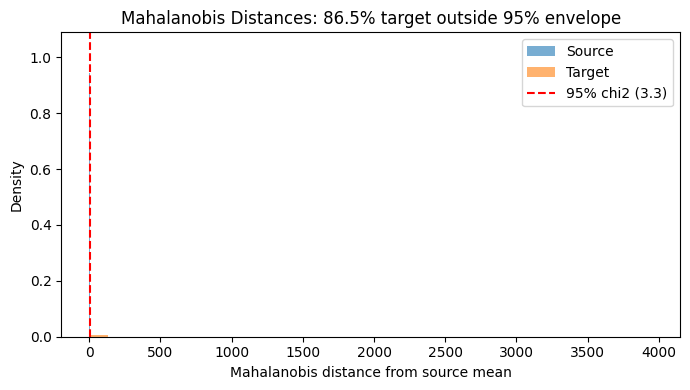

Saved nb01v2_mahal_summary.csv


In [16]:
# ── Mahalanobis distances ────────────────────────────────────────────────────
cov = np.cov(src_s.T)
try:
    cov_inv = np.linalg.inv(cov)
except np.linalg.LinAlgError:
    cov_inv = np.linalg.pinv(cov)

mean_src = src_s.mean(0)
d_src = np.array([mahalanobis(x, mean_src, cov_inv) for x in src_s])
d_tgt = np.array([mahalanobis(x, mean_src, cov_inv) for x in tgt_s])

threshold_95 = np.sqrt(chi2.ppf(0.95, df=len(features)))
out_src = (d_src > threshold_95).mean()
out_tgt = (d_tgt > threshold_95).mean()

print(f"Mahalanobis: source mean={d_src.mean():.2f}, target mean={d_tgt.mean():.2f}")
print(f"Outside 95% chi2 envelope: source={out_src:.1%}, target={out_tgt:.1%}")

fig, ax = plt.subplots(figsize=(7,4))
ax.hist(d_src, bins=30, alpha=0.6, label='Source', density=True)
ax.hist(d_tgt, bins=30, alpha=0.6, label='Target', density=True)
ax.axvline(threshold_95, color='r', linestyle='--', label=f'95% chi2 ({threshold_95:.1f})')
ax.set_xlabel('Mahalanobis distance from source mean')
ax.set_ylabel('Density')
ax.set_title(f'Mahalanobis Distances: {out_tgt:.1%} target outside 95% envelope')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'nb01v2_mahalanobis.png', dpi=80, bbox_inches='tight')
plt.show()

# Save summary
pd.DataFrame({'domain':['source','target'], 'mean_mahal':[d_src.mean(), d_tgt.mean()],
              'pct_outside_95':[out_src, out_tgt]}).to_csv(DATA_DIR+'nb01v2_mahal_summary.csv', index=False)
print("Saved nb01v2_mahal_summary.csv")
